In [1]:
from typing import Dict, TypedDict
from langgraph.graph import StateGraph

In [2]:
#Agent State
class AgentState(TypedDict):
    message: str

def greeting_node(state: AgentState) -> AgentState:
    """Simple node that adds a greeting message to the state"""

    state['message'] = "Hey " + state["message"] + ", how is your day going?"
    return state

In [3]:
graph = StateGraph(AgentState)

graph.add_node("greeter", greeting_node)
graph.set_entry_point("greeter")
graph.set_finish_point("greeter")

app = graph.compile()

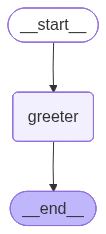

In [7]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [9]:
result = app.invoke({"message": "Long"})

In [11]:
result["message"]

'Hey Long, how is your day going?'

# Graph 2: Multi info Agent

In [14]:
from typing import Dict, TypedDict, List
from langgraph.graph import StateGraph

In [15]:
class AgentState(TypedDict):
    values: List[int]
    name: str
    result: str

In [16]:
def process_values(state: AgentState) -> AgentState:
    """This function handle multiple difffeent inputs"""
    state["result"] = f"Hi there {state["name"]}! Your sum = {sum(state["values"])}"
    return state

In [19]:
graph = StateGraph(AgentState)
graph.add_node("processor", process_values)
graph.set_entry_point("processor")
graph.set_finish_point("processor")

app = graph.compile()

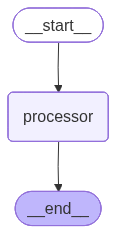

In [20]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [22]:
answer = app.invoke({"values": [1,2,3,4], "name": "Long"})

In [23]:
answer["result"]

'Hi there Long! Your sum = 10'

# Graph 3: Multi node

In [5]:
from typing import TypedDict
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    name: str
    age: str
    final: str

In [6]:
graph = StateGraph(AgentState)

In [9]:
def first_node(state: AgentState) -> AgentState:
    """First node"""
    state["final"] = f"Hi {state["name"]}!"
    return state
def second_node(state: AgentState) -> AgentState:
    """Second node"""
    state["final"] = state["final"] + f"You are {state["age"]} years old!"
    return state

In [11]:
graph = StateGraph(AgentState)
graph.add_node("first_node", first_node)
graph.add_node("second_node", second_node)

graph.set_entry_point("first_node")
graph.add_edge("first_node", "second_node")
graph.set_finish_point("second_node")

app = graph.compile()

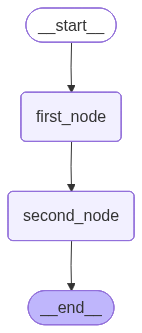

In [12]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [13]:
result = app.invoke({"name": "Long", "age": "28"})
print(result["final"])

Hi Long!You are 28 years old!


# Graph 4: Conditional Graph

In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [3]:
class AgentState(TypedDict):
    number1: int
    operation: str
    number2: int
    finalNumber: int

In [4]:
def adder(state: AgentState) -> AgentState:
    """Add number node"""
    state["finalNumber"] = state["number1"] + state["number2"]
    return state

def subtractor(state: AgentState) -> AgentState:
    """Subtract number node"""
    state["finalNumber"] = state["number1"] - state["number2"]
    return state

def router(state: AgentState) -> AgentState:
    """decider node"""
    if state["operation"] == "+":
        return "add_operation"
    elif state["operation"] == "-":
        return "subtract_operation"


In [7]:
graph = StateGraph(AgentState)
graph.add_node("add_node", adder)
graph.add_node("subtract_node", subtractor)
graph.add_node("router", lambda state:state)

graph.add_edge(START, "router")

graph.add_conditional_edges(
    "router",
    router,
    {
        "add_operation": "add_node",
        "subtract_operation": "subtract_node",
    }
)
graph.add_edge("add_node", END)
graph.add_edge("subtract_node", END)
app = graph.compile()

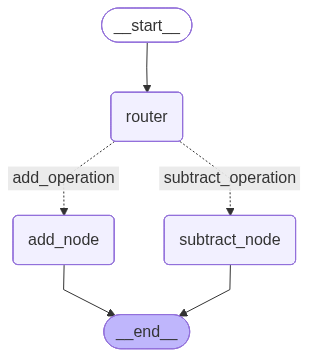

In [8]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [9]:
initial_state = AgentState(number1=1, operation="-", number2=2)
result = app.invoke(initial_state)
print(result)

{'number1': 1, 'operation': '-', 'number2': 2, 'finalNumber': -1}


# Exercise conditional graph

In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
class AgentState(TypedDict):
    number1: int
    number2: int
    number3: int
    number4: int
    operation: str
    operation2: str
    finalNumber: int
    finalNumber2: int

In [3]:
def add_node_1(state: AgentState) -> AgentState:
    state["finalNumber"] = state["number1"] + state["number2"]
    return state
def add_node_2(state: AgentState) -> AgentState:
    state["finalNumber2"] = state["number3"] + state["number4"]
    return state
def subtract_node_1(state: AgentState) -> AgentState:
    state["finalNumber"] = state["number1"] - state["number2"]
    return state
def subtract_node_2(state: AgentState) -> AgentState:
    state["finalNumber2"] = state["number3"] - state["number4"]
    return state
def router_node_1(state: AgentState) -> AgentState:
    if state["operation"] == "+":
        return "add_operation_1"
    elif state["operation"] == "-":
        return "subtract_operation_1"
def router_node_2(state: AgentState) -> AgentState:
    if state["operation2"] == "+":
        return "add_operation_2"
    elif state["operation2"] == "-":
        return "subtract_operation_2"

In [19]:
graph = StateGraph(AgentState)
graph.add_node("add_node_1", add_node_1)
graph.add_node("subtract_node_1", subtract_node_1)
graph.add_node("router1", lambda state:state)
graph.add_edge(START, "router1")
graph.add_conditional_edges(
    "router1",
    router_node_1,
    {
        "add_operation_1": "add_node_1",
        "subtract_operation_1": "subtract_node_1",
    }
)
graph.add_node("router2", lambda state:state)
graph.add_edge("add_node_1", "router2")
graph.add_edge("subtract_node_1", "router2")
graph.add_node("add_node_2", add_node_2)
graph.add_node("subtract_node_2", subtract_node_2)
graph.add_conditional_edges(
    "router2",
    router_node_2,
    {
        "add_operation_2": "add_node_2",
        "subtract_operation_2": "subtract_node_2",
    }
)
graph.add_edge("add_node_2", END)
graph.add_edge("subtract_node_2", END)
app = graph.compile()

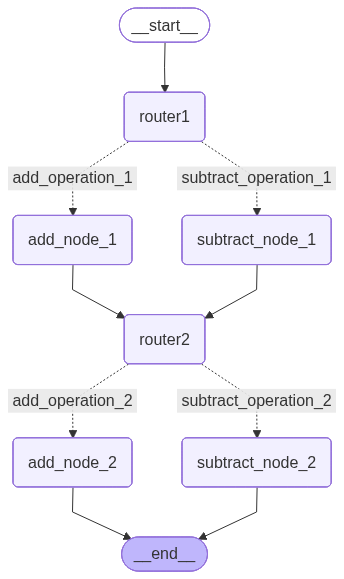

In [20]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

# Agent 1

In [10]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END
from langchain_ollama import OllamaLLM


In [11]:
class AgentState(TypedDict):
    question: str
    answer: str

In [12]:
llm = OllamaLLM(
        model="qwen2.5:7b",
        temperature=0
    )

In [13]:
def ask(state: AgentState) -> AgentState:
    state["answer"] = llm.invoke(state["question"])
    return state

In [14]:
graph = StateGraph(AgentState)
graph.add_node("ask", ask)
graph.add_edge(START, "ask")
graph.add_edge("ask", END)
app = graph.compile()

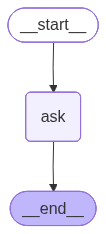

In [15]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [16]:
state_test = AgentState(
    {"question": "How many country in the world?"}
)

In [17]:
result = app.invoke(state_test)
print(result["answer"])

As of 2023, there are approximately 195 countries recognized by the United Nations. This number can be slightly different depending on how you count territories and dependencies, but 195 is a commonly cited figure.
